In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset
from src.diffusion import DDIMProcess
from src.misc import load_config
from src.predict import load_predictor


def predict_noise(model, images, steps, condition, guidance):
    if condition is None:
        return model(images, steps)
    if guidance == 1.0:
        return model(images, steps, condition)

    null = model(images, steps, torch.zeros_like(condition))
    guided = model(images, steps, condition)
    return null + guidance * (guided - null)


In [2]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"
SAMPLE_COUNT = 4
DDIM_STEPS = 20

In [3]:
config = load_config(PREDICT_CONFIG)
run_dir = ROOT / config["run_dir"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
predictor = load_predictor(run_dir, device=device)

data_config = Namespace(**load_config(run_dir / "model.yaml"))
data_config.data_dir = ROOT / data_config.data_dir
data_config.augment = False
dataset = build_dataset(data_config)
indices = torch.randint(len(dataset), (SAMPLE_COUNT,)).tolist()
real = torch.stack([dataset[index][0][0] for index in indices])

model = predictor.sampler.model
ddpm = predictor.sampler.ddpm
ddim = DDIMProcess(ddpm, min(DDIM_STEPS, ddpm.num_timesteps))
samples = torch.randn(
    SAMPLE_COUNT,
    predictor.num_phases,
    predictor.image_size,
    predictor.image_size,
    device=device,
)
fractions = config.get("phase_fractions")
condition = (
    None
    if fractions is None
    else torch.tensor(fractions, device=device).expand(SAMPLE_COUNT, -1)
)

with torch.no_grad():
    for step, prev_step in ddim.schedule:
        steps = torch.full((SAMPLE_COUNT,), step, dtype=torch.long, device=device)
        noise = predict_noise(
            model,
            samples,
            steps,
            condition,
            config["guidance_scale"],
        )
        samples = ddim.step(samples, noise, step=step, prev_step=prev_step)

generated = samples.argmax(dim=1).cpu()
counts = torch.bincount(generated.flatten(), minlength=predictor.num_phases)
sample_fractions = [round(value, 4) for value in (counts / counts.sum()).tolist()]
print(
    f"run={run_dir.name} steps={len(ddim.schedule)} "
    f"fractions={sample_fractions}"
)

run=20260716-065602-122839 steps=20 fractions=[0.5546, 0.1608, 0.2845]


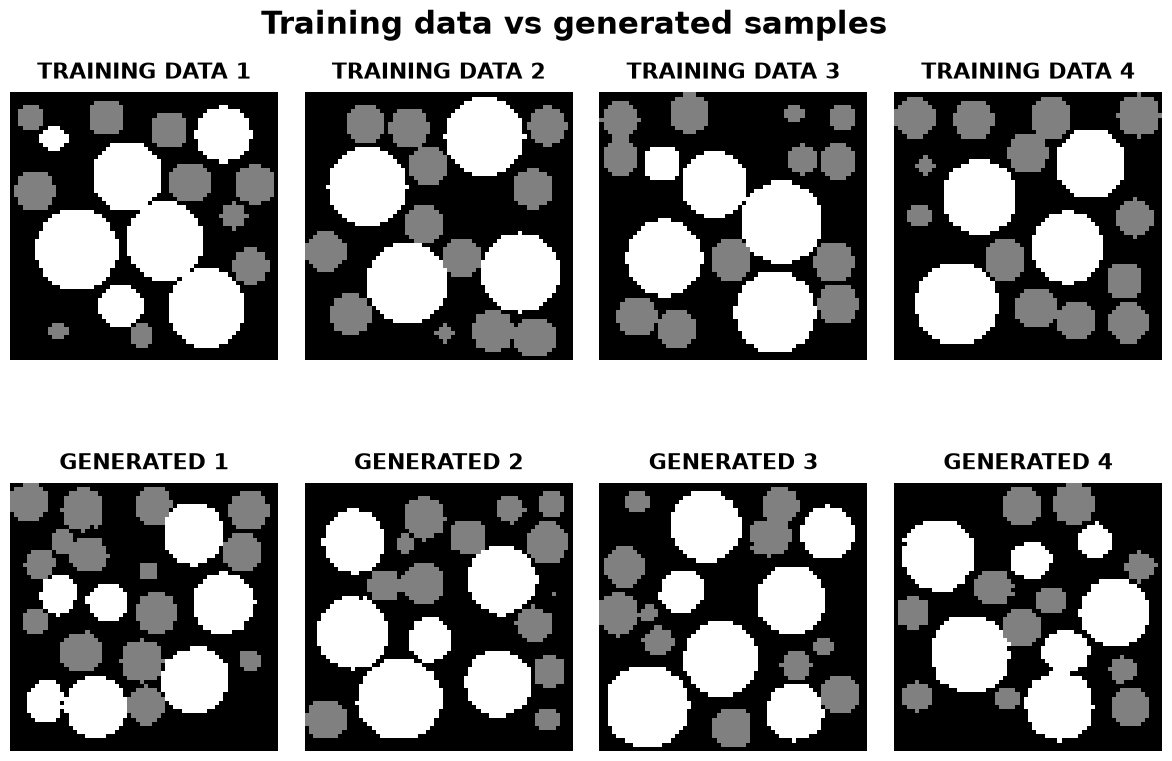

In [4]:
fig, axes = plt.subplots(
    2, SAMPLE_COUNT, figsize=(3 * SAMPLE_COUNT, 8), squeeze=False
)
for row, (images, title) in enumerate(
    ((real, "TRAINING DATA"), (generated, "GENERATED"))
):
    for column, (axis, image) in enumerate(zip(axes[row], images)):
        axis.imshow(
            image,
            cmap="gray",
            vmin=0,
            vmax=predictor.num_phases - 1,
            interpolation="nearest",
        )
        axis.set_title(
            f"{title} {column + 1}", fontsize=16, fontweight="bold", pad=10
        )
        axis.axis("off")
fig.suptitle(
    "Training data vs generated samples", fontsize=22, fontweight="bold", y=0.97
)
fig.subplots_adjust(left=0.03, right=0.99, bottom=0.03, top=0.88, wspace=0.10, hspace=0.35)
plt.show()